<a href="https://colab.research.google.com/github/elianramon/Machine_Learning_MCDM/blob/main/C%C3%B3pia_de_TCC_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERVICAL CANCER


## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cervical Cancer (cc)

In [ ]:
url_github = 'https://raw.githubusercontent.com/elianramon/Machine_Learning_MCDM/refs/heads/main/cervical-cancer_csv.csv'
cc_dataframe = pd.read_csv(url_github)

cc_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           810 non-null    float64
 2   First sexual intercourse            828 non-null    float64
 3   Num of pregnancies                  779 non-null    float64
 4   Smokes                              822 non-null    float64
 5   Smokes (years)                      822 non-null    float64
 6   Smokes (packs/year)                 822 non-null    float64
 7   Hormonal Contraceptives             732 non-null    float64
 8   Hormonal Contraceptives (years)     732 non-null    float64
 9   IUD                                 723 non-null    float64
 10  IUD (years)                         723 non-null    float64
 11  STDs                                735 non-n

# PRE-PROCESSING

### New Target

In [ ]:
# Definir as variáveis alvo (Hinselmann, Schiller, Citologia e Biópsia)

Hinselmann = [ 'Schiller', 'Citology', 'Biopsy']
Schiller = [ 'Hinselmann', 'Citology', 'Biopsy']
Citology = [ 'Hinselmann','Schiller', 'Biopsy']
Biopsy = [ 'Hinselmann', 'Schiller', 'Citology']

cc_dataframe.shape

(835, 36)

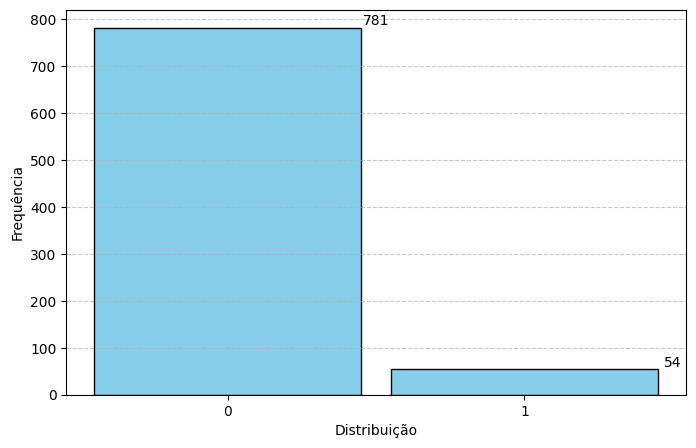

In [ ]:
import matplotlib.pyplot as plt

# Criar o histograma para visualizar a distribuição de `num_exames_indicando_cancer`
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(cc_dataframe['Biopsy'], bins=range(3), align='left', rwidth=0.9, color='skyblue', edgecolor='black')

# Configurações do gráfico
plt.xlabel('Distribuição')
plt.ylabel('Frequência')
plt.xticks(range(2))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores acima de cada barra
for i in range(len(n)):
    plt.text(bins[i] + 0.5, n[i], int(n[i]), ha='center', va='bottom')

# Exibir o gráfico
plt.show()


# DEF COM DROP E NORMALIZAÇÃO

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def inicial(dataframe, nome):

  # DROPE
  cc_dataframe_drop = cc_dataframe.drop(columns=dataframe)
  cc_dataframe_drop.shape

  # TRATAMENTO DE NULOS
  cc_dataframe_drop = cc_dataframe_drop.fillna(cc_dataframe_drop.mean())

  # DIVISÃO
  X = cc_dataframe_drop.drop(columns=[nome])  # Features
  y = cc_dataframe_drop[nome]  # Variável alvo

  # Inicializando o MinMaxScaler NORMALIZAÇÃO
  scaler = MinMaxScaler()

  # Aplicando o escalonamento às features
  X_scaled = scaler.fit_transform(X)

  # Convertendo de volta para um DataFrame para facilitar a visualização
  X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

  # Juntando as features escalonadas com a variável alvo novamente
  cc_dataframe_drop = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

  return cc_dataframe_drop

#DEF Reamostragem, Seleção de Features e Gráficos

In [ ]:
pip install -U imbalanced-learn


In [ ]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

def agilizadora(dataframe, nome):
  # ------------------------------------------------------------------------------------------------------------------------------------

  # Divisão do dataset
  X_drop = dataframe.drop(nome,axis=1)
  y_drop = dataframe[nome]

  # BorderlineSMOTE
  sm = SMOTETomek(random_state=42)
  X, y = sm.fit_resample(X_drop, y_drop)

  print(f'O tamanho de {nome} é {X.shape}')
  print('------------------------------------------------------------------------------------------------------------------------------------')

  # ------------------------------------------------------------------------------------------------------------------------------------

  cc_dataframe_smote = pd.DataFrame(X, columns=X.columns)
  cc_dataframe_smote[nome] = y

 # Contar a quantidade de amostras em cada classe após o oversampling
  class_counts_pre = dataframe[nome].value_counts()

  class_counts_post = cc_dataframe_smote[nome].value_counts()

  # Plotar o gráfico de pizza

  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  axes[0].pie(class_counts_pre, labels=class_counts_pre.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(class_counts_pre))))
  axes[0].set_title(f'Distribuição das Classe {nome} Pré-Oversampling')
  axes[0].axis('equal')  # Igualar o eixo para que o gráfico de pizza fique circular

  axes[1].pie(class_counts_post, labels=class_counts_post.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(class_counts_post))))
  axes[1].set_title(f'Distribuição das Classe {nome} Pós-Oversampling')
  axes[1].axis('equal')  # Igualar o eixo para que o gráfico de pizza fique circular


  # Exibir os gráficos
  plt.tight_layout()
  plt.show()
  print('------------------------------------------------------------------------------------------------------------------------------------')

  dataframe = pd.DataFrame(X, columns=X.columns)
  dataframe[nome] = y

  # Contar a quantidade de amostras em cada classe após o oversampling
  class_counts_post = dataframe[nome].value_counts()

  # ------------------------------------------------------------------------------------------------------------------------------------

  # REDUCTION FEATURES
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.model_selection import train_test_split

  # Dataset em treino e teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

  # Treinamento com Random Forest
  model = RandomForestClassifier(random_state=42)
  model.fit(X_train, y_train)

  # Obter a importância das features
  importances = model.feature_importances_
  # Identificar (np.argsort(importances)[-5:]) e selecionar (X.columns) os índices das 5 features mais importantes
  top_5_indices = np.argsort(importances)[-5:]
  top_5_features = X.columns[top_5_indices]
  # Atualização do dataframe com essas 5 features
  cc_dataframe_new = dataframe[top_5_features.tolist() + [nome]]
  print(f'top_5_features: {top_5_features.tolist()}', '\n')
  print('------------------------------------------------------------------------------------------------------------------------------------')
  print(f'Tamanho atual após feature selection {cc_dataframe_new.shape}')
  print('------------------------------------------------------------------------------------------------------------------------------------')
  # ------------------------------------------------------------------------------------------------------------------------------------

  # Plotagem das features de maior importância
  plt.figure(figsize=(10, 6))
  plt.barh(top_5_features, importances[top_5_indices], color='red')
  plt.xlabel('Importância')
  plt.ylabel('Features')
  plt.title(f'Top 5 Features de {nome}')
  plt.show()

  # ------------------------------------------------------------------------------------------------------------------------------------

  #  DIVISÃO DE TREINO E TESTE
  X = cc_dataframe_new.drop(nome, axis=1)
  y = cc_dataframe_new[nome]

  # Dataset em treino e teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
  print('------------------------------------------------------------------------------------------------------------------------------------')
  print(f'tamanho de X_train {X_train.shape}')
  print('------------------------------------------------------------------------------------------------------------------------------------')
  cc_dataframe_new.info()
  print('------------------------------------------------------------------------------------------------------------------------------------')
  # ------------------------------------------------------------------------------------------------------------------------------------

  return X_train, X_test, y_train, y_test

# TREINAMENTO

A partir de agora, preciso ver o que outros trabalhos consideraram



```
# Retorna as informaçoes de accuracy, precision, recall e F1 score de forma resulmida
  Paramets
    model (str)
    model_name (str)
    X_train, X_test, y_train, y_test
  Return
    print(accuracy, precision, recall e F1 score)

```



## DEF TREINAMENTO

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Função para treinar o modelo, calcular as métricas e salvar os resultados
def modelX(model, model_name, X_train, y_train, X_test, y_test, results):
    # Treinar o modelo
    model.fit(X_train, y_train)

    # Fazer previsões
    y_pred = model.predict(X_test)

    # Calcular as métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')

    # Adicionar os resultados ao DataFrame
    results.append([model_name, accuracy, precision, recall, f1])

In [ ]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# DEF MCDM

AHP-TOPSIS

In [ ]:
pip install ahpy


In [ ]:
import ahpy

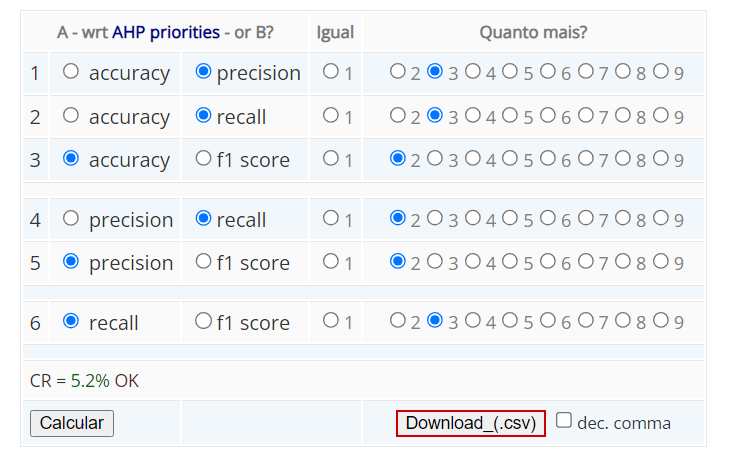

In [ ]:
# ------------------------------------------------------------------------------------------------------------------------------------
def AHP_TOPSIS(results_df, nome):

  criteria_comparisons = {
          ('Accuracy', 'Precision'): 0.333,
          ('Accuracy', 'Recall'): 0.333,
          ('Accuracy', 'F1 Score'): 2,
          ('Precision', 'Recall'): 0.5,
          ('Precision', 'F1 Score'): 2,
          ('Recall', 'F1 Score'): 3
      }

  # Criar o objeto de comparação de critérios
  criteria = ahpy.Compare(name='Criteria', comparisons=criteria_comparisons, precision=3)

  # Pesos dos critérios
  criteria_weights = criteria.target_weights
  print("Pesos dos critérios:", criteria_weights)
  print('------------------------------------------------------------------------------------------------------------------------------------')

  # Normalizar os resultados das métricas para 0-1 (não incluindo o modelo)
  normalized_results = results_df.iloc[:, 1:].apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

  # Multiplicar pelos pesos dos critérios
  weighted_results = normalized_results.copy()
  for criterion in criteria_weights:
      weighted_results[criterion] *= criteria_weights[criterion]

  # Somar as pontuações ponderadas para cada modelo
  results_df['AHP_Score'] = weighted_results.sum(axis=1)

  # Ordenar os resultados pelos scores AHP
  sorted_results = results_df.sort_values(by='AHP_Score', ascending=False)

  # Exibir os resultados ordenados
  sorted_results

  # ------------------------------------------------------------------------------------------------------------------------------------
  # ------------------------------------------------------------------------------------------------------------------------------------

  # TOPSIS
  # Determinar as soluções ideais positiva e negativa
  ideal_positive = weighted_results.max()
  ideal_negative = weighted_results.min()

  # Calcular as distâncias para a solução ideal positiva e negativa
  distance_to_positive = np.linalg.norm(weighted_results - ideal_positive, axis=1)
  distance_to_negative = np.linalg.norm(weighted_results - ideal_negative, axis=1)

  # Calcular a proximidade relativa
  proximity = distance_to_negative / (distance_to_positive + distance_to_negative)

  # Adicionar a coluna de proximidade ao DataFrame
  results_df['TOPSIS_R'] = proximity

  # Ordenar as alternativas com base na proximidade relativa
  sorted_results = results_df.sort_values(by='TOPSIS_R', ascending=False)

  # Exibir os resultados ordenados
  print(f'Ranqueamento para {nome}: \n {sorted_results}')

# **RESULTADOS HINSELMANN**

O tamanho de Hinselmann é (1594, 32)
------------------------------------------------------------------------------------------------------------------------------------


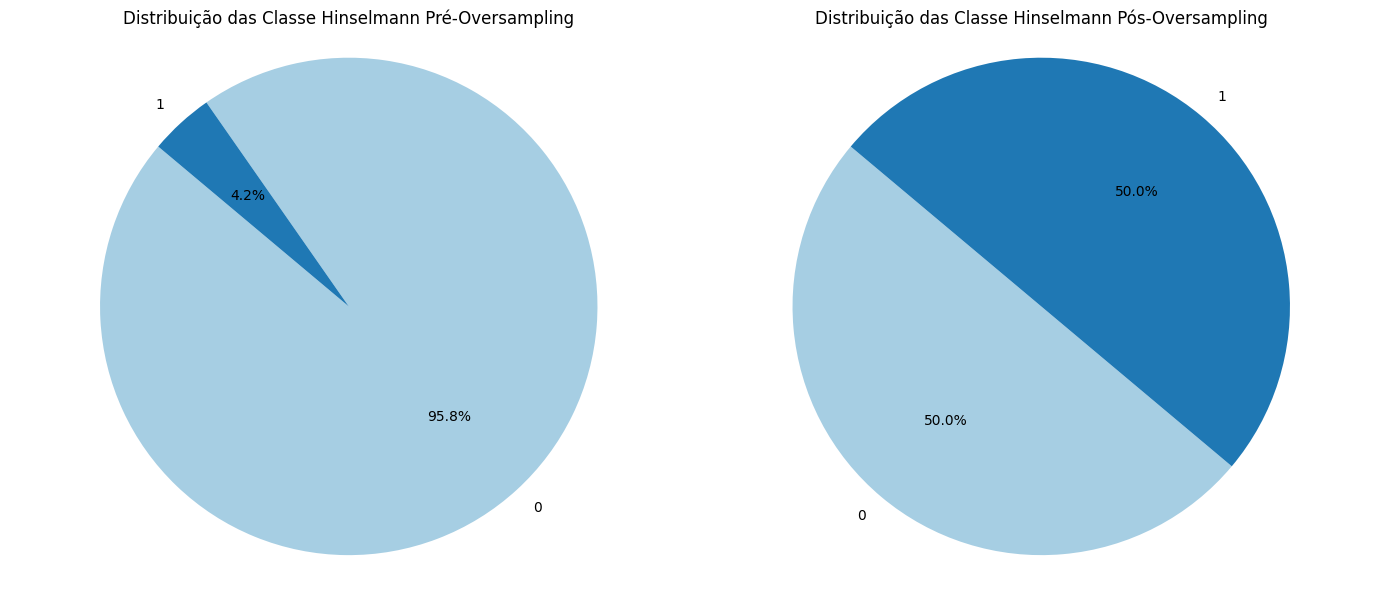

------------------------------------------------------------------------------------------------------------------------------------
top_5_features: ['Hormonal Contraceptives (years)', 'Age', 'First sexual intercourse', 'Number of sexual partners', 'Num of pregnancies'] 

------------------------------------------------------------------------------------------------------------------------------------
Tamanho atual após feature selection (1594, 6)
------------------------------------------------------------------------------------------------------------------------------------


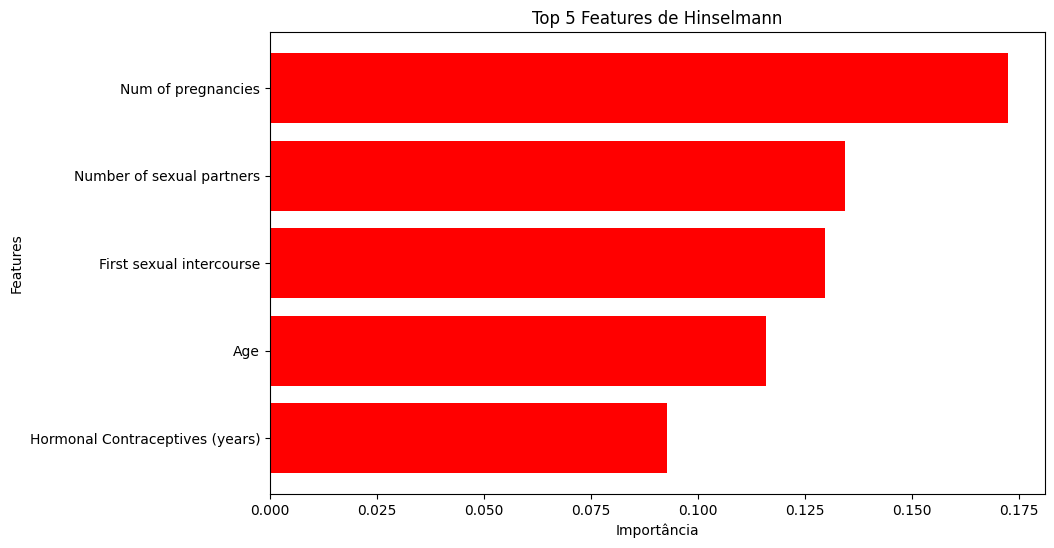

------------------------------------------------------------------------------------------------------------------------------------
tamanho de X_train (1115, 5)
------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Hormonal Contraceptives (years)  1594 non-null   float64
 1   Age                              1594 non-null   float64
 2   First sexual intercourse         1594 non-null   float64
 3   Number of sexual partners        1594 non-null   float64
 4   Num of pregnancies               1594 non-null   float64
 5   Hinselmann                       1594 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 74.8 KB
----------------------------------------------------

In [ ]:
cc_dataframe_drop = inicial(Hinselmann, 'Hinselmann')
X_train, X_test, y_train, y_test = agilizadora(cc_dataframe_drop, 'Hinselmann')

In [ ]:
# Preparação para armazenar os resultados
results = []

# Supondo que você tenha já X_train, y_train, X_test, y_test definidos

# Executando cada modelo e coletando os resultados
modelX(svm.SVC(probability=True), 'SVM', X_train, y_train, X_test, y_test, results)
modelX(RandomForestClassifier(random_state=42), 'Random Forest', X_train, y_train, X_test, y_test, results)
modelX(LogisticRegression(random_state=42, max_iter=100), 'Logistic Regression', X_train, y_train, X_test, y_test, results)
modelX(KNeighborsClassifier(n_neighbors=3), 'KNN', X_train, y_train, X_test, y_test, results)
modelX(GaussianNB(), 'Naive Bayes', X_train, y_train, X_test, y_test, results)
modelX(DecisionTreeClassifier(random_state=42), 'Decision Tree', X_train, y_train, X_test, y_test, results)

# Criar o DataFrame de resultados
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
results_df = pd.DataFrame(results, columns=columns)

# Exibir o DataFrame
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.728601   0.695804  0.822314  0.753788
1        Random Forest  0.954071   0.970085  0.938017  0.953782
2  Logistic Regression  0.615866   0.608209  0.673554  0.639216
3                  KNN  0.828810   0.773973  0.933884  0.846442
4          Naive Bayes  0.659708   0.607629  0.921488  0.732348
5        Decision Tree  0.893528   0.920705  0.863636  0.891258


In [ ]:
AHP_TOPSIS(results_df, 'Hinselmann')

Pesos dos critérios: {'Recall': np.float64(0.441), 'Precision': np.float64(0.29), 'Accuracy': np.float64(0.152), 'F1 Score': np.float64(0.117)}
------------------------------------------------------------------------------------------------------------------------------------
Ranqueamento para Hinselmann: 
                  Model  Accuracy  Precision    Recall  F1 Score  AHP_Score  \
1        Random Forest  0.954071   0.970085  0.938017  0.953782   1.000000   
5        Decision Tree  0.893528   0.920705  0.863636  0.891258   0.785995   
3                  KNN  0.828810   0.773973  0.933884  0.846442   0.739980   
4          Naive Bayes  0.659708   0.607629  0.921488  0.732348   0.467781   
0                  SVM  0.728601   0.695804  0.822314  0.753788   0.411892   
2  Logistic Regression  0.615866   0.608209  0.673554  0.639216   0.000464   

   TOPSIS_R  
1  1.000000  
5  0.762361  
3  0.732756  
4  0.556980  
0  0.455648  
2  0.000825  


# **RESULTADOS SCHILLER**

O tamanho de Schiller é (1492, 32)
------------------------------------------------------------------------------------------------------------------------------------


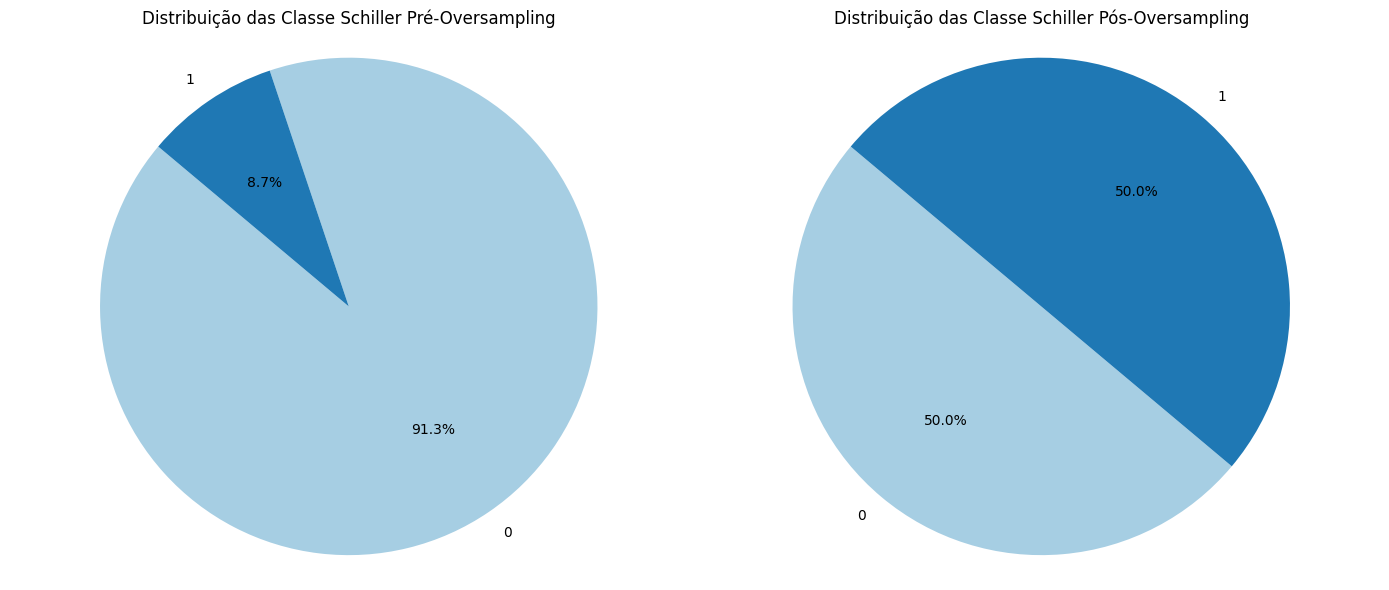

------------------------------------------------------------------------------------------------------------------------------------
top_5_features: ['Hormonal Contraceptives (years)', 'Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies'] 

------------------------------------------------------------------------------------------------------------------------------------
Tamanho atual após feature selection (1492, 6)
------------------------------------------------------------------------------------------------------------------------------------


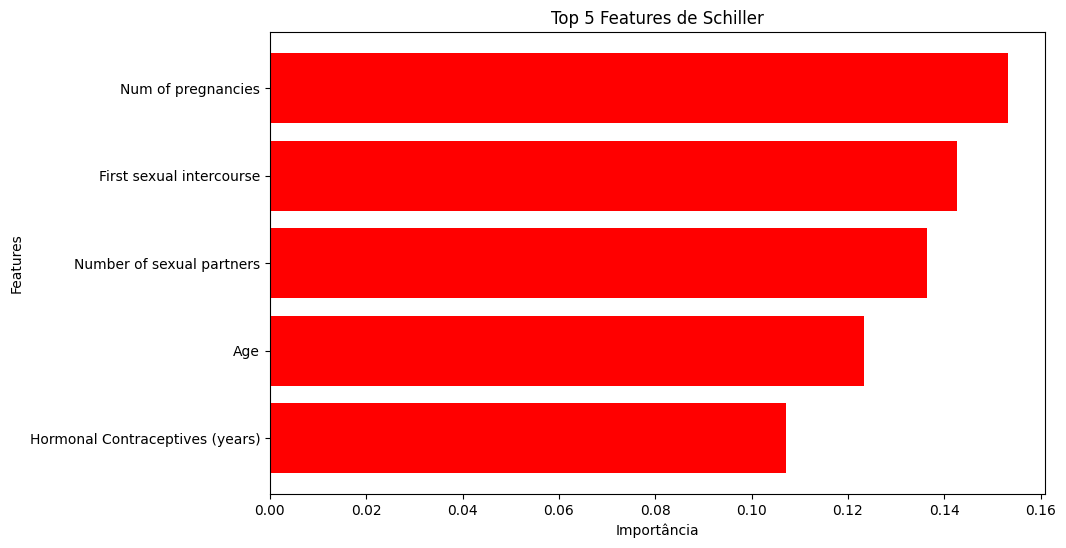

------------------------------------------------------------------------------------------------------------------------------------
tamanho de X_train (1044, 5)
------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Hormonal Contraceptives (years)  1492 non-null   float64
 1   Age                              1492 non-null   float64
 2   Number of sexual partners        1492 non-null   float64
 3   First sexual intercourse         1492 non-null   float64
 4   Num of pregnancies               1492 non-null   float64
 5   Schiller                         1492 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 70.1 KB
----------------------------------------------------

In [ ]:
cc_dataframe_drop = inicial(Schiller, 'Schiller')
X_train, X_test, y_train, y_test = agilizadora(cc_dataframe_drop, 'Schiller')

In [ ]:
# Preparação para armazenar os resultados
results = []

# Supondo que você tenha já X_train, y_train, X_test, y_test definidos

# Executando cada modelo e coletando os resultados
modelX(svm.SVC(probability=True), 'SVM', X_train, y_train, X_test, y_test, results)
modelX(RandomForestClassifier(random_state=42), 'Random Forest', X_train, y_train, X_test, y_test, results)
modelX(LogisticRegression(random_state=42, max_iter=100), 'Logistic Regression', X_train, y_train, X_test, y_test, results)
modelX(KNeighborsClassifier(n_neighbors=3), 'KNN', X_train, y_train, X_test, y_test, results)
modelX(GaussianNB(), 'Naive Bayes', X_train, y_train, X_test, y_test, results)
modelX(DecisionTreeClassifier(random_state=42), 'Decision Tree', X_train, y_train, X_test, y_test, results)

# Criar o DataFrame de resultados
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
results_df = pd.DataFrame(results, columns=columns)

# Exibir o DataFrame
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.640625   0.640000  0.692641  0.665281
1        Random Forest  0.917411   0.944954  0.891775  0.917595
2  Logistic Regression  0.549107   0.585799  0.428571  0.495000
3                  KNN  0.785714   0.736842  0.909091  0.813953
4          Naive Bayes  0.591518   0.606195  0.593074  0.599562
5        Decision Tree  0.866071   0.851852  0.896104  0.873418


In [ ]:
AHP_TOPSIS(results_df, 'Schiller')

Pesos dos critérios: {'Recall': np.float64(0.441), 'Precision': np.float64(0.29), 'Accuracy': np.float64(0.152), 'F1 Score': np.float64(0.117)}
------------------------------------------------------------------------------------------------------------------------------------
Ranqueamento para Schiller: 
                  Model  Accuracy  Precision    Recall  F1 Score  AHP_Score  \
1        Random Forest  0.917411   0.944954  0.891775  0.917595   0.984108   
5        Decision Tree  0.866071   0.851852  0.896104  0.873418   0.879487   
3                  KNN  0.785714   0.736842  0.909091  0.813953   0.748914   
0                  SVM  0.640625   0.640000  0.692641  0.665281   0.371030   
4          Naive Bayes  0.591518   0.606195  0.593074  0.599562   0.213894   
2  Logistic Regression  0.549107   0.585799  0.428571  0.495000   0.000000   

   TOPSIS_R  
1  0.971877  
5  0.864084  
3  0.726848  
0  0.424662  
4  0.265763  
2  0.000000  


# **RESULTADOS CITOLOGY**

O tamanho de Citology é (1562, 32)
------------------------------------------------------------------------------------------------------------------------------------


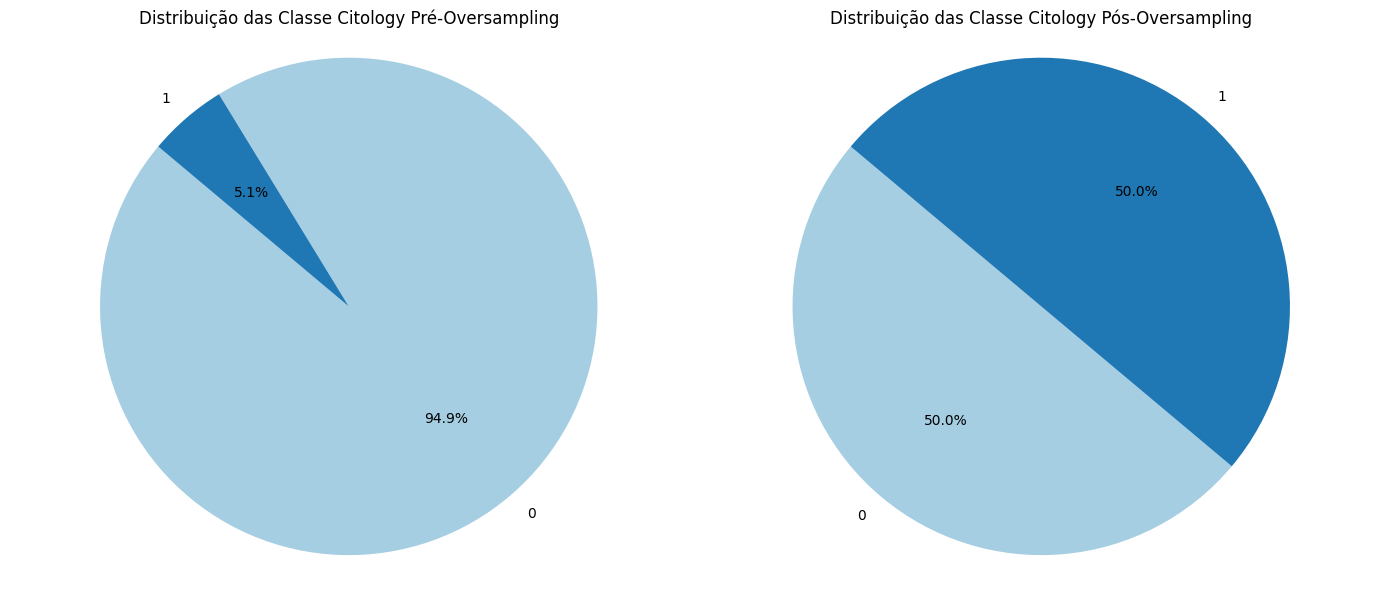

------------------------------------------------------------------------------------------------------------------------------------
top_5_features: ['Hormonal Contraceptives (years)', 'First sexual intercourse', 'Age', 'Number of sexual partners', 'Num of pregnancies'] 

------------------------------------------------------------------------------------------------------------------------------------
Tamanho atual após feature selection (1562, 6)
------------------------------------------------------------------------------------------------------------------------------------


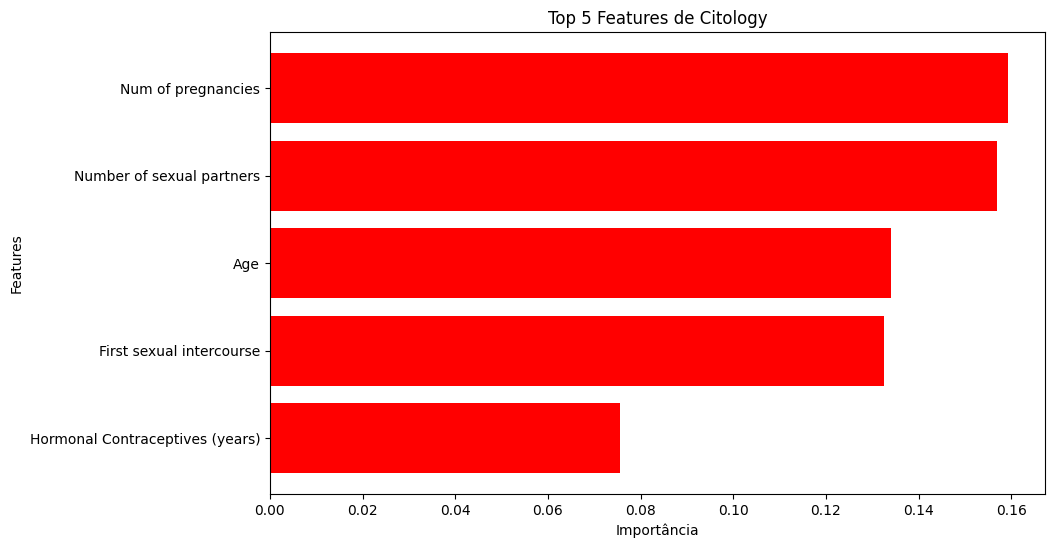

------------------------------------------------------------------------------------------------------------------------------------
tamanho de X_train (1093, 5)
------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1562 entries, 0 to 1561
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Hormonal Contraceptives (years)  1562 non-null   float64
 1   First sexual intercourse         1562 non-null   float64
 2   Age                              1562 non-null   float64
 3   Number of sexual partners        1562 non-null   float64
 4   Num of pregnancies               1562 non-null   float64
 5   Citology                         1562 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 73.3 KB
----------------------------------------------------

In [ ]:
cc_dataframe_drop = inicial(Citology, 'Citology')
X_train, X_test, y_train, y_test = agilizadora(cc_dataframe_drop, 'Citology')

In [ ]:
# Preparação para armazenar os resultados
results = []

# Supondo que você tenha já X_train, y_train, X_test, y_test definidos

# Executando cada modelo e coletando os resultados
modelX(svm.SVC(probability=True), 'SVM', X_train, y_train, X_test, y_test, results)
modelX(RandomForestClassifier(random_state=42), 'Random Forest', X_train, y_train, X_test, y_test, results)
modelX(LogisticRegression(random_state=42, max_iter=100), 'Logistic Regression', X_train, y_train, X_test, y_test, results)
modelX(KNeighborsClassifier(n_neighbors=3), 'KNN', X_train, y_train, X_test, y_test, results)
modelX(GaussianNB(), 'Naive Bayes', X_train, y_train, X_test, y_test, results)
modelX(DecisionTreeClassifier(random_state=42), 'Decision Tree', X_train, y_train, X_test, y_test, results)

# Criar o DataFrame de resultados
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
results_df = pd.DataFrame(results, columns=columns)

# Exibir o DataFrame
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.646055   0.619377  0.761702  0.683206
1        Random Forest  0.938166   0.947826  0.927660  0.937634
2  Logistic Regression  0.605544   0.581169  0.761702  0.659300
3                  KNN  0.752665   0.705882  0.868085  0.778626
4          Naive Bayes  0.597015   0.569277  0.804255  0.666667
5        Decision Tree  0.904051   0.902542  0.906383  0.904459


In [ ]:
AHP_TOPSIS(results_df, 'Citology')

Pesos dos critérios: {'Recall': np.float64(0.441), 'Precision': np.float64(0.29), 'Accuracy': np.float64(0.152), 'F1 Score': np.float64(0.117)}
------------------------------------------------------------------------------------------------------------------------------------
Ranqueamento para Citology: 
                  Model  Accuracy  Precision    Recall  F1 Score  AHP_Score  \
1        Random Forest  0.938166   0.947826  0.927660  0.937634   1.000000   
5        Decision Tree  0.904051   0.902542  0.906383  0.904459   0.879625   
3                  KNN  0.752665   0.705882  0.868085  0.778626   0.506853   
4          Naive Bayes  0.597015   0.569277  0.804255  0.666667   0.116173   
0                  SVM  0.646055   0.619377  0.761702  0.683206   0.070280   
2  Logistic Regression  0.605544   0.581169  0.761702  0.659300   0.012910   

   TOPSIS_R  
1  1.000000  
5  0.876336  
3  0.540943  
4  0.191627  
0  0.078059  
2  0.017446  


# **RESULTADOS BIOPSY**

O tamanho de Biopsy é (1544, 32)
------------------------------------------------------------------------------------------------------------------------------------


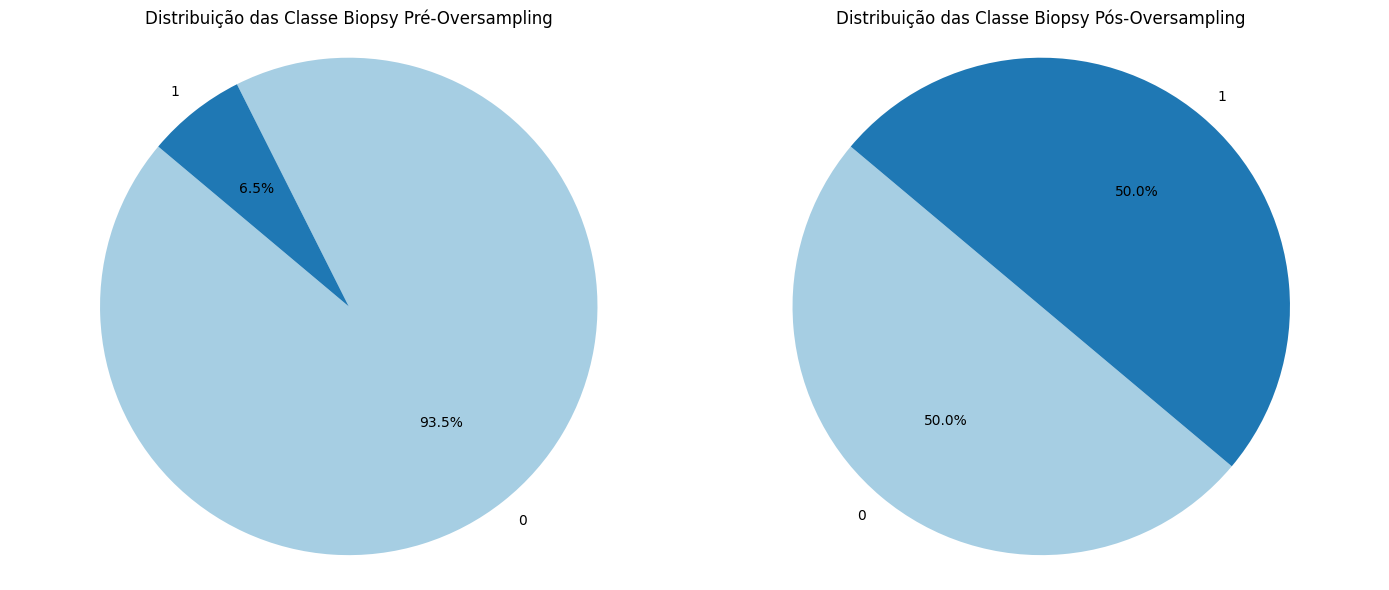

------------------------------------------------------------------------------------------------------------------------------------
top_5_features: ['Hormonal Contraceptives (years)', 'Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies'] 

------------------------------------------------------------------------------------------------------------------------------------
Tamanho atual após feature selection (1544, 6)
------------------------------------------------------------------------------------------------------------------------------------


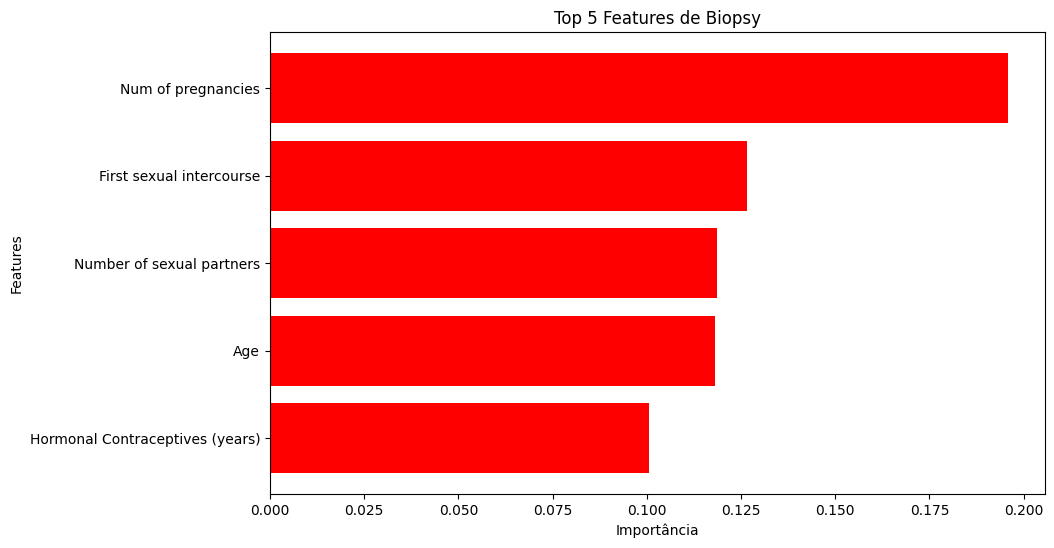

------------------------------------------------------------------------------------------------------------------------------------
tamanho de X_train (1080, 5)
------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Hormonal Contraceptives (years)  1544 non-null   float64
 1   Age                              1544 non-null   float64
 2   Number of sexual partners        1544 non-null   float64
 3   First sexual intercourse         1544 non-null   float64
 4   Num of pregnancies               1544 non-null   float64
 5   Biopsy                           1544 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 72.5 KB
----------------------------------------------------

In [ ]:
cc_dataframe_drop = inicial(Biopsy, 'Biopsy')
X_train, X_test, y_train, y_test = agilizadora(cc_dataframe_drop, 'Biopsy')

In [ ]:
# Preparação para armazenar os resultados
results = []

# Supondo que você tenha já X_train, y_train, X_test, y_test definidos

# Executando cada modelo e coletando os resultados
modelX(svm.SVC(probability=True), 'SVM', X_train, y_train, X_test, y_test, results)
modelX(RandomForestClassifier(random_state=42), 'Random Forest', X_train, y_train, X_test, y_test, results)
modelX(LogisticRegression(random_state=42, max_iter=100), 'Logistic Regression', X_train, y_train, X_test, y_test, results)
modelX(KNeighborsClassifier(n_neighbors=3), 'KNN', X_train, y_train, X_test, y_test, results)
modelX(GaussianNB(), 'Naive Bayes', X_train, y_train, X_test, y_test, results)
modelX(DecisionTreeClassifier(random_state=42), 'Decision Tree', X_train, y_train, X_test, y_test, results)

# Criar o DataFrame de resultados
columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
results_df = pd.DataFrame(results, columns=columns)

# Exibir o DataFrame
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.717672   0.683333  0.850622  0.757856
1        Random Forest  0.948276   0.950207  0.950207  0.950207
2  Logistic Regression  0.517241   0.557823  0.340249  0.422680
3                  KNN  0.814655   0.764505  0.929461  0.838951
4          Naive Bayes  0.665948   0.661654  0.730290  0.694280
5        Decision Tree  0.903017   0.911765  0.900415  0.906054


In [ ]:
AHP_TOPSIS(results_df, 'Biopsy')

Pesos dos critérios: {'Recall': np.float64(0.441), 'Precision': np.float64(0.29), 'Accuracy': np.float64(0.152), 'F1 Score': np.float64(0.117)}
------------------------------------------------------------------------------------------------------------------------------------
Ranqueamento para Biopsy: 
                  Model  Accuracy  Precision    Recall  F1 Score  AHP_Score  \
1        Random Forest  0.948276   0.950207  0.950207  0.950207   1.000000   
5        Decision Tree  0.903017   0.911765  0.900415  0.906054   0.909835   
3                  KNN  0.814655   0.764505  0.929461  0.838951   0.775957   
0                  SVM  0.717672   0.683333  0.850622  0.757856   0.606779   
4          Naive Bayes  0.665948   0.661654  0.730290  0.694280   0.471416   
2  Logistic Regression  0.517241   0.557823  0.340249  0.422680   0.000000   

   TOPSIS_R  
1  1.000000  
5  0.911832  
3  0.761973  
0  0.632287  
4  0.511241  
2  0.000000  
